# Clasificación de sentimiento: EDA (Análisis exploratorio de los datos) 
En esta celda, vamos a visualizar los datos de nuestro dataset artificial para crear un modelo de NLP que clasifique el prompt introducido por el usuario en 4 categorías:
- Inaceptable
- Alto riesgo
- Riesgo limitado
- Riesgo mínimo

Esto es un ejercicio similar al análisis de sentimiento que hemos realizado durante el módulo, pero en este caso, se conoce como text classification supervisada multiclase, no sentiment analysis. 


In [6]:
import sys
import os

# Localizar src/classifier/ de forma robusta y ajustar cwd al directorio
# de este notebook para que rutas relativas (datasets/, data/, model/) funcionen
# independientemente de desde donde se lance Jupyter/VS Code.
_cwd = os.getcwd()
_candidates = [
    os.path.join(_cwd, "src", "classifier"),
    os.path.abspath(".."),
    os.path.abspath("."),
]
for _p in _candidates:
    if os.path.isfile(os.path.join(_p, "functions.py")):
        if _p not in sys.path:
            sys.path.insert(0, _p)
        # Cambiar cwd al directorio de este notebook
        os.chdir(os.path.join(_p, "classifier_ultimo_dataset"))
        break

import functions  # noqa: E402
functions.MLFLOW_EXPERIMENT = "clasificador_riesgo_ultimo_dataset"
functions._DATASET_TAGS = {"dataset_type": "ultimo", "dataset_source": "dataset_sintetico_v2"}

In [7]:
#Al principio de cada notebook, añadimos estas líneas para que se recarguen automáticamente las funciones que hayamos editado en el módulo functions.py sin tener que reiniciar el kernel cada vez.
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Carga del dataset 
Cargamos el dataset y lo guardamos en archivos separados 

In [8]:
# Abrimos el dataset
import pandas as pd
path = "datasets/dataset_sintetico_v2.csv"
df = pd.read_csv(path)
# Separamos las características (X) y la variable objetivo (y)
X = df["descripcion"]
y = df["etiqueta"]


# Imprimimos las formas de los conjuntos de entrenamiento y prueba
print("Conjunto:", X.shape, y.shape)

Conjunto: (285,) (285,)


# Primer acercamiento a los datos: 

1. Verificaciones básicas
Objetivo: confirmar que no hay nulos ni clases desbalanceadas.
2. Comprobar duplicados
3. Longitud de los textos
4. Limpieza mínima del texto
5. Generación de un word cloud para comprobar las palabras más utilizadas 

In [9]:
#Comprobamos si nuestro dataset tenía duplicados antes de la división
df.duplicated().sum()

np.int64(0)

In [10]:
# Mostramos las primeras filas del conjunto de entrenamiento
X.head()
# Mostramos las últimas filas del conjunto de entrenamiento
X.tail()


280    Programa que evalúa el riesgo de impago de emp...
281    Chatbot gubernamental que recopila opiniones c...
282    Programa que usa el análisis de marcha de pers...
283    Programa que ayuda a redactar correos profesio...
284    Sistema de riego automático que ajusta la cant...
Name: descripcion, dtype: object

In [11]:
# Mostramos las últimas filas del conjunto de entrenamiento
y.head()
# mostramos las últimas filas del conjunto de entrenamiento
y.tail()

280        alto_riesgo
281        inaceptable
282        inaceptable
283    riesgo_limitado
284      riesgo_minimo
Name: etiqueta, dtype: object

<Axes: xlabel='etiqueta'>

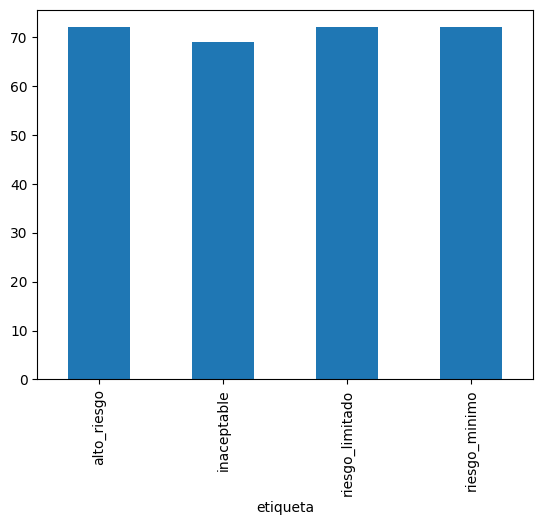

In [12]:
# Comprobamos la distribución de las etiquetas en el conjunto de entrenamiento
df['etiqueta'].value_counts().sort_index().plot(kind='bar')

# 1️ Distribución de clases:
Como vemos en el gráfico anterior, el dataset está bastante equilibrado:
- alto_riesgo ≈ 90
- inaceptable ≈ 77
- riesgo_limitado ≈ 67
- riesgo_minimo ≈ 66


In [13]:
# Analizamos la longitud de las descripciones para ver si hay alguna diferencia entre las clases
df["longitud"] = df["descripcion"].apply(len)
df["longitud"].describe()

count    285.000000
mean     127.119298
std       24.220956
min       81.000000
25%      109.000000
50%      125.000000
75%      141.000000
max      200.000000
Name: longitud, dtype: float64

In [14]:
# Comprobamos el tamaño del vocabulario bruto
raw_vocab = set(" ".join(df['descripcion']).split())
len(raw_vocab)

765

In [15]:
#Creamos una nueva columna con el texto limpio
from functions import limpiar_texto

df["descripcion_limpia"] = df["descripcion"].apply(limpiar_texto)

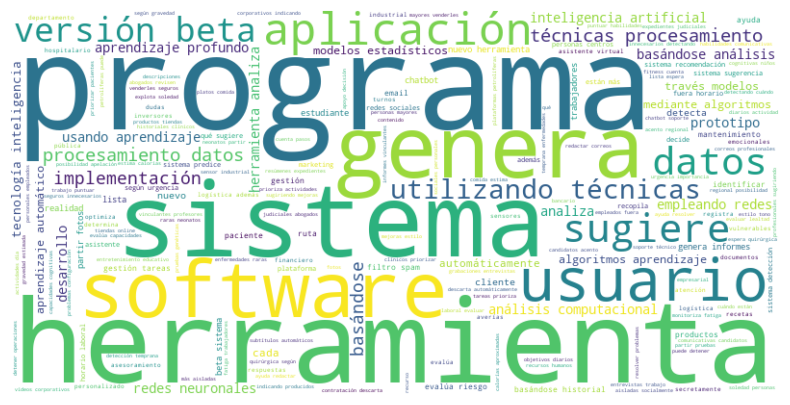

In [16]:
#Creamos un wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt
# Unimos todas las descripciones limpias en un solo texto
texto_completo = " ".join(df["descripcion_limpia"])
# Creamos el wordcloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(texto_completo)
# Mostramos el wordcloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

# Wordcloud
Palabras dominantes:
- sistema
- algoritmo
- automáticamente
- supervisión
- revisión
- herramienta
- usuario
- biométrica
- reconocimiento
- Interpretación:

El dataset gira alrededor de cuatro ejes claros:

- Automatización
- Supervisión humana
- Identificación biométrica
- Impacto sobre personas

Eso encaja perfectamente con el AI Act.


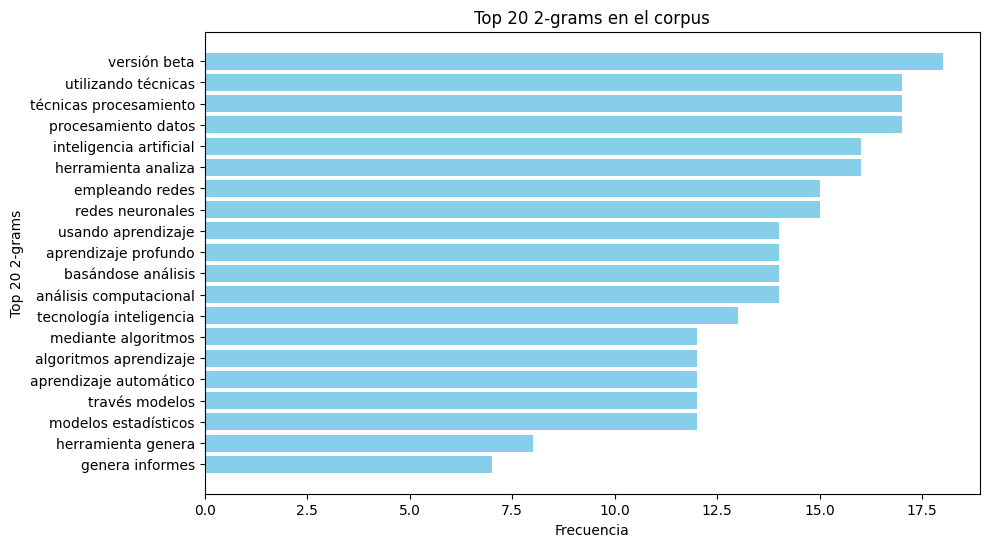

[('versión beta', 18), ('utilizando técnicas', 17), ('técnicas procesamiento', 17), ('procesamiento datos', 17), ('inteligencia artificial', 16), ('herramienta analiza', 16), ('empleando redes', 15), ('redes neuronales', 15), ('usando aprendizaje', 14), ('aprendizaje profundo', 14), ('basándose análisis', 14), ('análisis computacional', 14), ('tecnología inteligencia', 13), ('mediante algoritmos', 12), ('algoritmos aprendizaje', 12), ('aprendizaje automático', 12), ('través modelos', 12), ('modelos estadísticos', 12), ('herramienta genera', 8), ('genera informes', 7)]


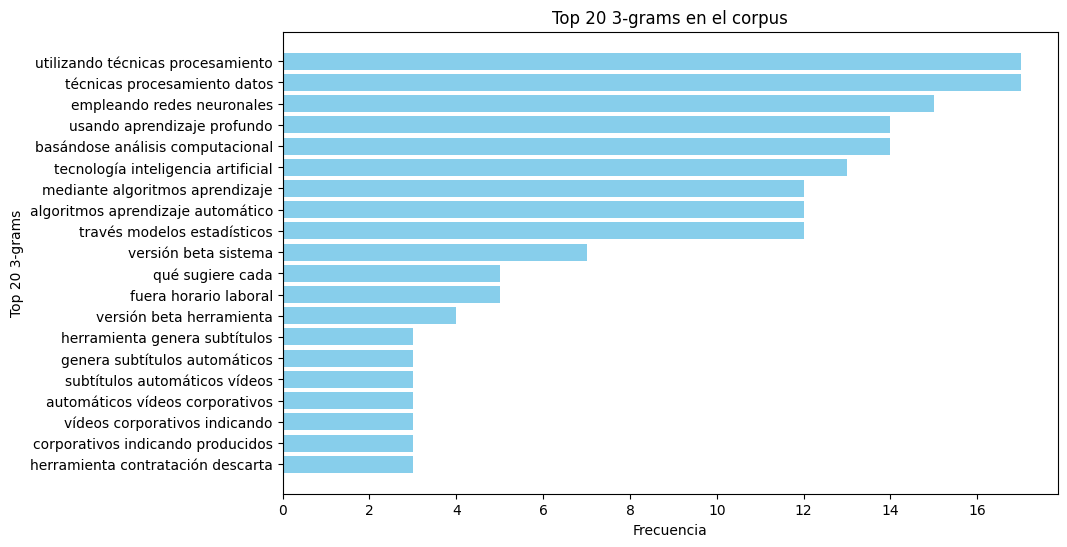

[('utilizando técnicas procesamiento', 17), ('técnicas procesamiento datos', 17), ('empleando redes neuronales', 15), ('usando aprendizaje profundo', 14), ('basándose análisis computacional', 14), ('tecnología inteligencia artificial', 13), ('mediante algoritmos aprendizaje', 12), ('algoritmos aprendizaje automático', 12), ('través modelos estadísticos', 12), ('versión beta sistema', 7), ('qué sugiere cada', 5), ('fuera horario laboral', 5), ('versión beta herramienta', 4), ('herramienta genera subtítulos', 3), ('genera subtítulos automáticos', 3), ('subtítulos automáticos vídeos', 3), ('automáticos vídeos corporativos', 3), ('vídeos corporativos indicando', 3), ('corporativos indicando producidos', 3), ('herramienta contratación descarta', 3)]


In [17]:
#Comprobamos los n-gramas más comunes
from functions import top_ngrams
print(top_ngrams(df, n=20, ngram=2))
print(top_ngrams(df, n=20, ngram=3))

# N-grams (2 y 3)
Ahora el corpus refleja señal semántica real:
Aparecen patrones como:
- “determina automáticamente”
- “revisión humana”
- “identificación biométrica”
- “reconocimiento facial”
- “evaluación riesgo”
- “tiempo real”
- “genera automáticamente”
Conclusión:
El texto contiene vocabulario discriminativo.
El modelo puede aprender reglas regulatorias reales.
La limpieza eliminó bastante ruido estructural.

# Conclusiones del análisis exploratorio: 
(En este caso, recopilo todo lo comprendido anteriormente y añado algunas ideas más que surgen después de tener visión del conjunto)
 1️ Distribución de clases
El dataset está bastante equilibrado:
- alto_riesgo ≈ 90
- inaceptable ≈ 77
- riesgo_limitado ≈ 67
- riesgo_minimo ≈ 66

2️ N-grams (2 y 3)
Ahora el corpus refleja señal semántica real:
Aparecen patrones como:
- “determina automáticamente”
- “revisión humana”
- “identificación biométrica”
- “reconocimiento facial”
- “evaluación riesgo”
- “tiempo real”
- “genera automáticamente”

Conclusión:
El texto contiene vocabulario discriminativo.
El modelo puede aprender reglas regulatorias reales.
La limpieza eliminó bastante ruido estructural.

3️ Wordcloud
Palabras dominantes:
- sistema
- algoritmo
- automáticamente
- supervisión
- revisión
- herramienta
- usuario
- biométrica
- reconocimiento
- Interpretación:

El dataset gira alrededor de cuatro ejes claros:

- Automatización
- Supervisión humana
- Identificación biométrica
- Impacto sobre personas

Eso encaja perfectamente con el AI Act.

4️ Riesgo potencial detectado
Aún hay redacción relativamente homogénea:
Muchos textos empiezan por:
- “sistema…”
- “algoritmo…”
- “herramienta…”

Riesgo:
El modelo puede aprender patrones editoriales además de patrones legales.
No es crítico ahora, pero a futuro conviene introducir variabilidad lingüística.

5️ Señales fuertes que el modelo puede usar
- Muy probablemente el clasificador aprende asociaciones como:
- biométrico + tiempo real → inaceptable
- revisión humana → riesgo limitado
- determina automáticamente → alto riesgo
- advertir / identificar como IA → limitado
- consentimiento / vulnerabilidad → inaceptable
- Eso es coherente con la regulación.

6️ Conclusión general del EDA

Nuestro dataset, generado artificialmente utilizando IA:

- Está bien balanceado
- Tiene vocabulario regulatorio claro
- Tiene patrones discriminativos útiles
- Es adecuado para ML clásico
- Es suficientemente rico para intentar fine-tuning después

Debilidad principal:
Homogeneidad estilística.

In [18]:
# Guardamos el dataset limpio para usarlo en el siguiente notebook
df.to_csv("datasets/dataset_sintetico_v2_limpio.csv", index=False)

In [19]:
# ── MLflow (solo falla esta celda si el servidor no está disponible) ──
from functions import log_mlflow_safe

dist = df["etiqueta"].value_counts()

try:
    log_mlflow_safe(
        run_name="eda",
        params={
            "n_samples": len(df),
            "n_clases": df["etiqueta"].nunique(),
            "text_column": "descripcion",
            "raw_vocab_size": len(set(" ".join(df["descripcion"]).split())),
        },
        metrics={
            "n_alto_riesgo":     int(dist.get("alto_riesgo", 0)),
            "n_inaceptable":     int(dist.get("inaceptable", 0)),
            "n_riesgo_limitado": int(dist.get("riesgo_limitado", 0)),
            "n_riesgo_minimo":   int(dist.get("riesgo_minimo", 0)),
            "longitud_media":    round(df["longitud"].mean(), 2),
            "longitud_std":      round(df["longitud"].std(), 2),
        },
    )
    print("✓ EDA registrado en MLflow")
except Exception as e:
    print(f"⚠ MLflow no disponible: {e}")

Password obtenida desde variable de entorno local.
MLflow configurado correctamente → https://18.201.64.41/
⚠ MLflow no disponible: API request to https://18.201.64.41/api/2.0/mlflow/experiments/get-by-name failed with timeout exception HTTPSConnectionPool(host='18.201.64.41', port=443): Max retries exceeded with url: /api/2.0/mlflow/experiments/get-by-name?experiment_name=clasificador_riesgo_ultimo_dataset (Caused by ConnectTimeoutError(<HTTPSConnection(host='18.201.64.41', port=443) at 0x2b669c3a1e0>, 'Connection to 18.201.64.41 timed out. (connect timeout=120)')). To increase the timeout, set the environment variable MLFLOW_HTTP_REQUEST_TIMEOUT (default: 120, type: int) to a larger value.
